In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

#import os


In [ ]:
#os.chdir('C:\\Users\\weido\\ch3_basic_nn')
#os.getcwd()

In [2]:
image_size = 28 # width and length
no_of_different_labels = 10 #  i.e. 0, 1, 2, 3, ..., 9
image_pixels = image_size * image_size
#data_path = "machine_learning/"
train_data = np.loadtxt("C:/machine_learning/NN_nn_overview/mnist_train.csv", 
                        delimiter=",")
test_data = np.loadtxt("C:/machine_learning/NN_nn_overview/mnist_test.csv", 
                       delimiter=",") 


In [3]:
fac = 0.99/255 # convert [0,255] to [0,1]
train_imgs = np.asfarray(train_data[:, 1:])*fac+0.01
test_imgs = np.asfarray(test_data[:, 1:])*fac+0.01
# first column is labels

train_labels = np.asfarray(train_data[:,:1])
test_labels = np.asfarray(test_data[:, :1])


In [4]:
print ('The shape of train_imgs is: ' + str(train_imgs.shape))
print ('The shape of train_labels is: ' + str(train_labels.shape))
print ('The shape of test_imgs is: ' + str(test_imgs.shape))
print ('The shape of test_labels is: ' + str(test_labels.shape))

The shape of train_imgs is: (60000, 784)
The shape of train_labels is: (60000, 1)
The shape of test_imgs is: (10000, 784)
The shape of test_labels is: (10000, 1)


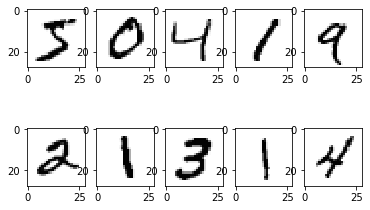

In [5]:
# display the first 10 examples
for i in range(10):
    img = train_imgs[i].reshape((28,28))
    plt.subplot(2,5,1+i)
    plt.imshow(img, cmap="Greys")
plt.show()
 


In [6]:
np.random.seed(1) # set a seed so that the results are consistent

lr = np.arange(no_of_different_labels)

# transform labels into one hot representation
train_labels_one_hot = (lr==train_labels).astype(np.float)
test_labels_one_hot = (lr==test_labels).astype(np.float)

X=np.transpose(train_imgs)
Y=np.transpose(train_labels_one_hot)
X_test=np.transpose(test_imgs)


### find the shape of X and Y
### find the number of examples
shape_X = X.shape
shape_Y = Y.shape
m = X.shape[1]  # training set size
 
print ('The shape of X is ' + str(shape_X))
print ('The shape of Y is ' + str(shape_Y))
print ('the number of examples is m = %d' % (m))


The shape of X is (784, 60000)
The shape of Y is (10, 60000)
the number of examples is m = 60000


In [10]:
# Neural network from scratch
def softmax(x):
    t=np.exp(x)
    s = t/np.sum(t, axis=0)
    
    return s


In [8]:
def layer_sizes(X, Y):  
    """  
    Argument:  
    X -- input dataset of shape (input size, number of examples)  
    Y -- labels of shape (output size, number of examples)  
    Return:  
    n_x -- the number of nodes in the input layer  
    n_y -- the number of nodes in the output layer  
    """  
    ### extract the layer sizes from input and output shapes ### 
    n_x = X.shape[0] # size of input layer  
    n_y = Y.shape[0] # size of output layer  
    ######  
    return (n_x, n_y)  


In [9]:
# FUNCTION: initialize_parameters  
  
def initialize_parameters(n_x, n_h, n_y):  
    """  
    Argument:  
    n_x -- size of the input layer  
    n_h -- size of the hidden layer  
    n_y -- size of the output layer  
    Returns:  
    params -- python dictionary containing parameters:  
                    W1 -- weight matrix of shape (n_h, n_x)  
                    b1 -- bias vector of shape (n_h, 1)  
                    W2 -- weight matrix of shape (n_y, n_h)  
                    b2 -- bias vector of shape (n_y, 1)  
    """  
    np.random.seed(2) # set up a seed for reproductivity.  
        
    W1 = np.random.randn(n_h, n_x) * 0.01  # random numbers for weights
    b1 = np.zeros((n_h, 1))                # zeros for bias
    W2 = np.random.randn(n_y, n_h) * 0.01  
    b2 = np.zeros((n_y,1))  

    assert (W1.shape == (n_h, n_x))  
    assert (b1.shape == (n_h, 1))  
    assert (W2.shape == (n_y, n_h))  
    assert (b2.shape == (n_y, 1))  
      
    parameters = {"W1": W1,  
                  "b1": b1,  
                  "W2": W2,  
                  "b2": b2}  
      
    return parameters  


In [11]:
# FUNCTION: forward_propagation  

def forward_propagation(X, parameters):  
    """  
    Argument:  
    X -- input data of size (n_x, m)  
    parameters -- python dictionary containing your parameters (output of initialization function)  
      
    Returns:  
    A2 -- The softmax output of the second activation  
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2"  
    """  
    # Retrieve each parameter from the dictionary "parameters"  
    W1 = parameters["W1"]  
    b1 = parameters["b1"]  
    W2 = parameters["W2"]  
    b2 = parameters["b2"]  
      
    # Implement Forward Propagation to calculate A2 (probabilities)   
    Z1 = np.dot(W1, X) + b1  
    A1 =  np.tanh(Z1)  
    Z2 = np.dot(W2, A1) + b2  
    
    # multiple classes
    A2 = softmax(Z2)
    assert(A2.shape == (W2.shape[0], X.shape[1]))  #for multiple classes
    
    cache = {"Z1": Z1,  
             "A1": A1,  
             "Z2": Z2,  
             "A2": A2}  
      
    return A2, cache  


In [13]:
# FUNCTION: compute_cost  

def compute_cost(A2, Y, parameters):  
    """  
    Computes the cross-entropy cost  
      
    Arguments:  
    A2 -- The softmax output of the second activation, of shape (n_y, number of examples)  
    Y -- "true" labels vector of shape (n_y, number of examples)  
    parameters -- python dictionary containing your parameters W1, b1, W2 and b2  
      
    Returns:  
    cost -- cross-entropy cost  
    """  
      
    m = Y.shape[1] # number of example  
  
    # for multiple-class task
    logprobs = np.multiply(np.log(A2),Y)
    cost = -1/m*np.sum(logprobs)  
    cost = np.squeeze(cost)     # makes sure cost is the dimension we expect.   
                                # E.g., turns [[17]] into 17   
    assert(isinstance(cost, float))  
      
    return cost  


In [14]:
# FUNCTION: backward_propagation  
  
def backward_propagation(parameters, cache, X, Y):  
    """  
    Implement the backward propagation  
      
    Arguments:  
    parameters -- python dictionary containing our parameters   
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2".  
    X -- input data of shape (n_x, number of examples)  
    Y -- "true" labels vector of shape (n_y, number of examples)  
      
    Returns:  
    grads -- python dictionary containing your gradients with respect to different parameters  
    """  
    m = X.shape[1]  
      
    # First, retrieve W1 and W2 from the dictionary "parameters".   
    W1 = parameters["W1"]  
    W2 = parameters["W2"]  
          
    # Retrieve also A1 and A2 from dictionary "cache".  
    A1 = cache["A1"]  
    A2 =  cache["A2"]  
    
    # Backward propagation: calculate dW1, db1, dW2, db2.     
    dZ2= A2-Y  
    dW2 = 1./m*np.dot(dZ2, A1.T)  
    db2 = 1./m*np.sum(dZ2, axis = 1, keepdims=True)  
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))  
    dW1 = 1./m* np.dot(dZ1, X.T)  
    db1 = 1./m*np.sum(dZ1, axis = 1, keepdims=True)  
    
    grads = {"dW1": dW1,  
             "db1": db1,  
             "dW2": dW2,  
             "db2": db2}  
      
    return grads  


In [15]:
#  FUNCTION: update_parameters  
  
def update_parameters(parameters, grads, learning_rate = 1.2):  
    """  
    Updates parameters using the gradient descent  
      
    Arguments:  
    parameters -- python dictionary containing your parameters   
    grads -- python dictionary containing your gradients   
      
    Returns:  
    parameters -- python dictionary containing your updated parameters   
    """  
    # Retrieve each parameter from the dictionary "parameters"   
    W1 = parameters["W1"]  
    W2 = parameters["W2"]  
    b1 = parameters["b1"]  
    b2 = parameters["b2"]  
    
    # Retrieve each gradient from the dictionary "grads"  
    dW1 = grads["dW1"]  
    db1 = grads["db1"]  
    dW2 = grads["dW2"]  
    db2 = grads["db2"]  
      
    # Update rule for each parameter   
    W1 = W1 - dW1 * learning_rate  
    b1 = b1 - db1 * learning_rate  
    W2 = W2 - dW2 * learning_rate  
    b2 = b2 - db2 * learning_rate  
   
    parameters = {"W1": W1,  
                  "b1": b1,  
                  "W2": W2,  
                  "b2": b2}  
      
    return parameters  


In [18]:
# FUNCTION: nn_model  
  
def nn_model(X, Y, n_h, num_iterations = 10000, print_cost=False):  
    """  
    Arguments:  
    X -- dataset of shape (n_x, number of examples)  
    Y -- labels of shape (n_y, number of examples)  
    n_h -- size of the hidden layer  
    num_iterations -- Number of iterations in gradient descent loop  
    print_cost -- if True, print the cost every 1000 iterations  
      
    Returns:  
    parameters -- parameters learnt by the model. They can then be used to predict.  
    """  
    np.random.seed(3)  
    n_x = layer_sizes(X, Y)[0]  
    n_y = layer_sizes(X, Y)[1]  
      
    # Initialize parameters, 
    # then retrieve W1, b1, W2, b2. 
    # Inputs: "n_x, n_h, n_y". Outputs = "W1, b1, W2, b2 in parameters".   
    parameters = initialize_parameters(n_x, n_h, n_y)  
    W1 = parameters["W1"]  
    W2 = parameters["W2"]  
    b1 = parameters["b1"]  
    b2 = parameters["b2"]  
    
    # Loop (gradient descent)  
  
    for i in range(0, num_iterations):  
            
        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".  
        A2, cache = forward_propagation(X, parameters)  
          
        # Cost function. Inputs: "A2, Y, parameters". Outputs: "cost".  
        cost = compute_cost(A2, Y, parameters)  
   
        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".  
        grads = backward_propagation(parameters, cache, X, Y)  
   
        # Gradient descent parameter update. Inputs: "parameters, grads". Outputs: "parameters".  
        parameters = update_parameters(parameters, grads)  
           
        # Print the cost every 1000 iterations  
        if print_cost and i % 10 == 0:  
            print ("Cost after iteration %i: %f" %(i, cost))  
  
    return parameters  


In [19]:
# FUNCTION: predict  
  
def predict(parameters, X):  
    """  
    Using the learned parameters, predicts a class for each example in X  
      
    Arguments:  
    parameters -- python dictionary containing your parameters   
    X -- input data of size (n_x, m)  
      
    Returns  
    predictions -- vector of predictions
    """  
      
    # Computes probabilities using forward propagation, 
    # and classifies by argmax.  
    
    A2, cache = forward_propagation(X, parameters)  
    
    # for multiple classes
    # use argmax to find the digit:  np.argmax(a, axis=0)
    predictions = np.argmax(A2, axis=0)
  
    return predictions  


In [20]:
from sklearn.metrics import accuracy_score 
# Build a model with a n_h-dimensional hidden layer  
n_h=25
parameters = nn_model(X, Y, n_h, num_iterations = 100, print_cost=True)  
    
predictions = predict(parameters, X) 
accuracy_train = accuracy_score(train_labels.flatten(),predictions)  
print('Accuracy of training: ', accuracy_train)  
    
predictions = predict(parameters, X_test) 
accuracy_test = accuracy_score(test_labels.flatten(), predictions)
print('Accuracy of test: ', accuracy_test) 

 
  



Cost after iteration 0: 2.302137
Cost after iteration 10: 1.239301
Cost after iteration 20: 0.902871
Cost after iteration 30: 0.530826
Cost after iteration 40: 0.465360
Cost after iteration 50: 0.398585
Cost after iteration 60: 0.345182
Cost after iteration 70: 0.321645
Cost after iteration 80: 0.313386
Cost after iteration 90: 0.325701
Accuracy of training:  0.92115
Accuracy of test:  0.9254


In [42]:
parameters1=initialize_parameters(2, 2, 1)

In [43]:
W1=parameters1["W1"]
b1=parameters1["b1"]
W2=parameters1["W2"]
b2=parameters1["b2"]

In [45]:
W1

array([[-0.00416758, -0.00056267],
       [-0.02136196,  0.01640271]])

In [ ]:
predictions.shape